In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [59]:
df = pd.read_csv("diabetes.csv")
print(df.shape)
print(df.head())

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values.reshape(-1, 1)

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

In [25]:
#activation functions
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(x))

# Architecture of NN

Input -> Hiddien 1 -> Hidden 2 -> Output
  8         16           8           1

In [55]:
lr = 1e-3
dropout_rate = 0.2
epochs = 200
batch_size = 32
global w1, b1, w2, b2, w3, b3
np.random.seed(42)
w1 = np.random.randn(8, 16) * np.sqrt(2 / 8)
b1 = np.zeros((1, 16))

w2 = np.random.randn(16, 8) * np.sqrt(2 / 16)
b2 = np.zeros((1, 8))

w3 = np.random.randn(8, 1) * np.sqrt(2 / 8)
b3 = np.zeros((1, 1))

In [49]:
def forward_backward(X, y_true, lr=1e-3, dropout_rate=0.2, training=True):

    #forward
    #input to hidden 1
    z1 = X @ w1 + b1
    a1 = relu(z1)
    if training:
        d1 = (np.random.rand(*a1.shape) > dropout_rate).astype(float)
        a1 = a1 * d1 / (1 - dropout_rate + 1e-8)
    else:
        d1 = np.ones_like(a1)

    #hidden 1 to hidden 2
    z2 = a1 @ w2 + b2
    a2 = relu(z2)
    if training:
        d2 = (np.random.rand(*a2.shape) > dropout_rate).astype(float)
        a2 = a2 * d2 / (1 - dropout_rate + 1e-8)
    else:
        d2 = np.ones_like(a2)

    #hidden 2 to output
    z3 = a2 @ w3 + b3
    a3 = sigmoid(z3)

    # loss with entropy
    eps = 1e-8
    loss = -np.mean(y_true * np.log(A3 + eps) + (1- y_true) * np.log(1 - A3 + eps))

    error = a3 - y_true

    #backward
    if training:
        m = X.shape[0]

        dw3 = a2.T @ error / m
        db3 = np.mean(error, axis=0, keepdims=True)

        da2 = error @ w3.T
        da2 = da2 * d2 / (1 - dropout_rate + 1e-8)
        dz2 = da2 * relu_deriv(z2)
        dw2 = a1.T @ dz2 / m
        db2 = np.mean(dz2, axis=0, keepdims=True)

        da1 = dz2 @ w2.T
        da1 = da1 * d1 / (1 - dropout_rate + 1e-8)
        dz1 = da1 * relu_deriv(z1)
        dw1 = X.T @ dz1 / m
        db1 = np.mean(dz1, axis=0, keepdims=True)

        w3 -= lr * dw3
        b3 -= lr * db3
        w2 -= lr * dw2
        b2 -= lr * db2
        w1 -= lr * dw1
        b1 -= lr * db1
    return A3, loss

In [51]:
def train(X_train, y_train, X_val, y_val, lr=1e-3, dropout_rate=0.2):
    train_losses = []
    for epoch in range(epochs):
        idx = np.random.permutation(len(X_train))
        X_s, y_s = X_train[idx], y_train[idx]

        batch_losses = []
        for i in range(0, len(X_s), batch_size):
            Xb = X_s[i:i+batch_size]
            yb = y_s[i:i+batch_size]

            _, loss = forward_backward(Xb, yb, lr, dropout_rate, training=True)
            batch_lossses.append(loss)

        epoch_loss = np.mean(batch_losses)
        train_losses.append(epoch_loss)

        if (epoch + 1) % 50 == 0:
                print(f"  Epoch {epoch+1:3d} | Train Loss: {epoch_loss:.4f} ")
    return train_losses

In [31]:
def predict(X):
    probs, _ = forward_backward(X, training=False)
    return (probs >= 0.5).astype(int)

def accuracy(X, y):
    return np.mean(predict(X) == y)


========== Learning Rate Experiment ==========

Learning Rate = 0.01


UnboundLocalError: cannot access local variable 'w1' where it is not associated with a value

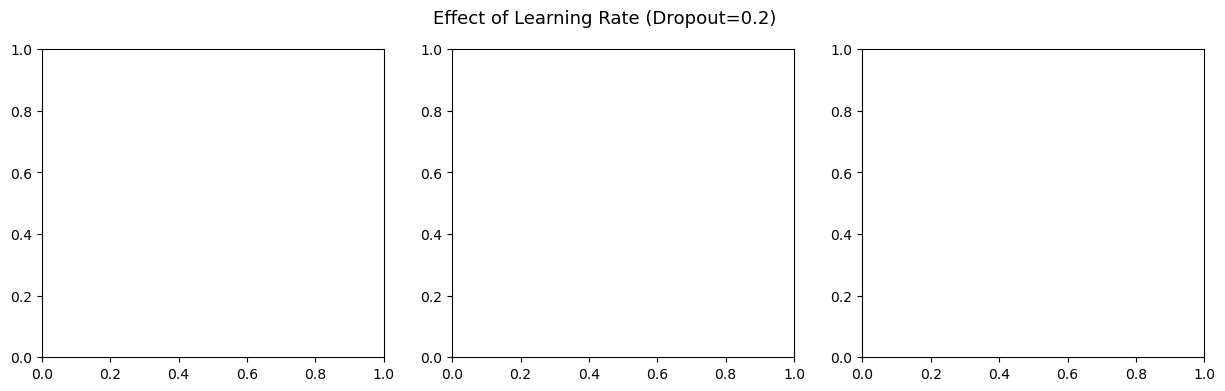

In [61]:
print("\n========== Learning Rate Experiment ==========")
learning_rates = [1e-2, 1e-3, 1e-4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Effect of Learning Rate (Dropout=0.2)", fontsize=13)

for ax, lr in zip(axes, learning_rates):
    print(f"\nLearning Rate = {lr}")
    t_loss = train(X_train, y_train, X_val, y_val, lr, 0.2)
    val_acc = accuracy(X_val, y_val)
    print(f"  → Val Accuracy: {val_acc:.4f}")

    ax.plot(t_loss, label="Train Loss")
    ax.set_title(f"LR = {lr}\nVal Acc = {val_acc:.2%}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()